# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [2]:
import pandas as pd

# Загрузка файла
df = pd.read_csv("data/Advertising.csv")

# Просмотр первых 5 строк
print(df.head())


   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [3]:
# Проверяем наличие пропущенных значений
print(df.isnull().sum())

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [4]:
#ваш код 

**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [5]:
import numpy as np

# Разделение на признаки и целевую переменную
X = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values

# Проверка размеров
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (200, 3)
y shape: (200,)


## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [6]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [7]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [8]:
num_iters = 1000
m, n = X.shape  # m — количество строк, n — количество признаков
w = np.zeros((n, 1))  # Инициализируем веса нулями (вектор столбец)
loss_history = []

for i in range(num_iters):
    for k in range(n):
        # Прогноз без k-го признака: h = X_без_k @ w_без_k
        h = X[:, :k] @ w[:k] + X[:, k+1:] @ w[k+1:]
        
        # Обновляем вес k-го признака
        w[k] = (X[:, k].T @ (y - h)).reshape(1)

    # Вычисляем предсказания и функцию потерь
    y_pred = X @ w
    loss = ((y - y_pred).T @ (y - y_pred)) / m
    loss_history.append(loss.item())  # Добавляем скалярное значение потерь

# Вывод финальных весов
print("Финальные веса модели:")
print(w)


Финальные веса модели:
[[ 41.56217205]
 [110.13144155]
 [ 73.52860638]
 [ -0.55006384]]


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [9]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_)

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

In [10]:
X_features = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values.reshape(-1, 1)

# Масштабируем признаки (z-score стандартизация)
X_features_scaled = (X_features - X_features.mean(axis=0)) / X_features.std(axis=0)


**Добавим единичный столбец**

In [11]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [12]:
w = np.zeros((X.shape[1], 1))  # (4, 1)

def mse_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

y_pred = X @ w
error = mse_error(y, y_pred)
print("Среднеквадратичная ошибка:", error)


Среднеквадратичная ошибка: 223.71625


**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [13]:
# Наивный прогноз: предсказываем среднее значение по y
y_mean = np.mean(y)
y_pred_naive = np.full_like(y, fill_value=y_mean)  # тот же размер, все значения = среднее

error_naive = mse_error(y, y_pred_naive)
print("Среднеквадратичная ошибка (наивный прогноз):", error_naive)


Среднеквадратичная ошибка (наивный прогноз): 27.085743750000002


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [14]:
def lin_pred(X, w):
    """
    Возвращает предсказания линейной модели по данным X и весам w.
    
    Parameters:
    X -- матрица признаков размером (m, n)
    w -- вектор весов размером (n, 1)
    
    Returns:
    y_pred -- вектор предсказаний размером (m, 1)
    """
    return X @ w


# Допустим, w пока нулевой
w = np.zeros((X.shape[1], 1))

# Предсказание:
y_pred = lin_pred(X, w)

# Проверка формы:
print("y_pred shape:", y_pred.shape)  # Должно быть (200, 1)


y_pred shape: (200, 1)


**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [15]:
def stoch_grad_step(X, y, w, train_ind, eta):
    """
    Выполняет один шаг стохастического градиентного спуска по train_ind.

    Parameters:
    X         -- матрица признаков (m, n)
    y         -- вектор правильных значений (m, 1)
    w         -- вектор весов (n, 1)
    train_ind -- индекс строки в X, по которой делается шаг
    eta       -- шаг градиентного спуска

    Returns:
    w_new     -- обновлённый вектор весов (n, 1)
    """
    m = X.shape[0]  # число примеров
    x_i = X[train_ind].reshape(1, -1)      # (1, n)
    y_i = y[train_ind]                     # (1,)

    y_hat = x_i @ w                        # (1, 1)
    error = y_hat - y_i                    # (1, 1)

    gradient = (2 / m) * x_i.T * error     # (n, 1)
    w_new = w - eta * gradient             # обновление весов

    return w_new

eta = 0.01
train_ind = 0  # обновим по первой строке
w_new = stoch_grad_step(X, y, w, train_ind, eta)

print("Обновлённые веса после одного шага SGD:")
print(w_new.T)


Обновлённые веса после одного шага SGD:
[[0.00221    0.00015627 0.00021131 0.00021419 0.00028845]]


**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [16]:
def stochastic_gradient_descent(X, y, w_init, eta=0.01, max_iter=10000, min_weight_dist=1e-6):
    """
    Выполняет стохастический градиентный спуск.

    Parameters:
    X               -- матрица признаков (m, n)
    y               -- вектор правильных ответов (m, 1)
    w_init          -- начальный вектор весов (n, 1)
    eta             -- шаг обучения
    max_iter        -- максимальное число итераций
    min_weight_dist -- минимальное изменение весов для остановки

    Returns:
    w               -- итоговый вектор весов
    errors          -- список ошибок (MSE) на каждой итерации
    """
    w = w_init.copy()
    weight_dist = float('inf')
    errors = []
    iter_num = 0

    while weight_dist > min_weight_dist and iter_num < max_iter:
        train_ind = np.random.randint(0, X.shape[0])  # случайный индекс
        
        y_pred = lin_pred(X, w)
        errors.append(mse_error(y, y_pred))  # записываем ошибку
        
        w_new = stoch_grad_step(X, y, w, train_ind, eta)  # один шаг SGD
        
        weight_dist = np.linalg.norm(w_new - w)  # евклидово расстояние между w_new и w
        w = w_new
        iter_num += 1

    return w, errors

# Начальные веса
w_init = np.zeros((X.shape[1], 1))

# Параметры обучения
eta = 0.01
max_iter = 10000
min_weight_dist = 1e-6

# Запуск
w_final, error_list = stochastic_gradient_descent(X, y, w_init, eta, max_iter, min_weight_dist)

print("Финальные веса:")
print(w_final.T)

print("Последняя ошибка:", error_list[-1])


Финальные веса:
[[6.47824697 0.45808124 0.48267783 0.45763067 0.40726176]]
Последняя ошибка: 82.03185501728404


 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

Финальные веса после 100000 итераций:
[[13.62945522  0.96374802  2.26127824  1.92201104  1.2463741 ]]
Финальная ошибка: 25.889646681257265


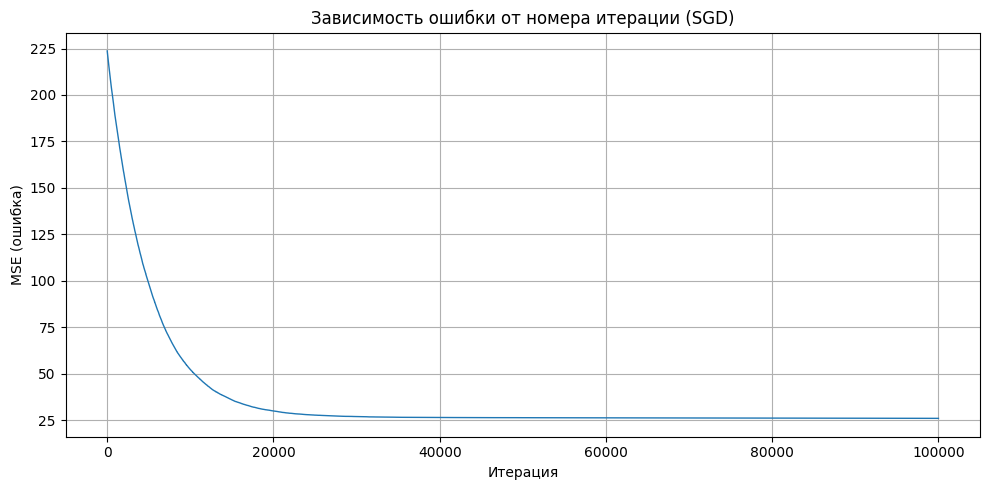

In [17]:
w_init = np.zeros((X.shape[1], 1))  # начальные веса
eta = 0.01                          # темп обучения (можно поэкспериментировать)
max_iter = 100_000                 # 10^5 итераций

# Запуск обучения
w_final, error_list = stochastic_gradient_descent(
    X, y, w_init, eta=eta, max_iter=max_iter, min_weight_dist=1e-9  # min_weight_dist почти ноль, чтобы не останавливалось рано
)

print("Финальные веса после 100000 итераций:")
print(w_final.T)
print("Финальная ошибка:", error_list[-1])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(error_list, linewidth=1)
plt.xlabel("Итерация")
plt.ylabel("MSE (ошибка)")
plt.title("Зависимость ошибки от номера итерации (SGD)")
plt.grid(True)
plt.tight_layout()
plt.show()


**Выведите вектор весов, к которому сошелся метод.**

In [20]:
# Преобразуем вектор весов в столбец и округлим до 4 знаков:
w_vector = w_final.reshape(-1, 1)  # теперь форма (5, 1)
print("Финальный вектор весов:\n", np.round(w_vector, 4))



Финальный вектор весов:
 [[13.6295]
 [ 0.9637]
 [ 2.2613]
 [ 1.922 ]
 [ 1.2464]]


**Выведите среднеквадратичную ошибку на последней итерации.**

In [22]:
print("Среднеквадратичная ошибка на последней итерации:", error_list[-1])



Среднеквадратичная ошибка на последней итерации: 25.889646681257265
